In [8]:
import json

from aizynthfinder.reactiontree import ReactionTree

# path to the trees.json produced by aizynthcli / run.py
trees_path = "../tree_8312.json"

with open(trees_path) as f:
    trees = json.load(f)


In [9]:
print(f"Number of routes: {len(trees)}")


Number of routes: 6


{'state score': 0.994039853898894, 'number of reactions': 3, 'number of pre-cursors': 4, 'number of pre-cursors in stock': 4}


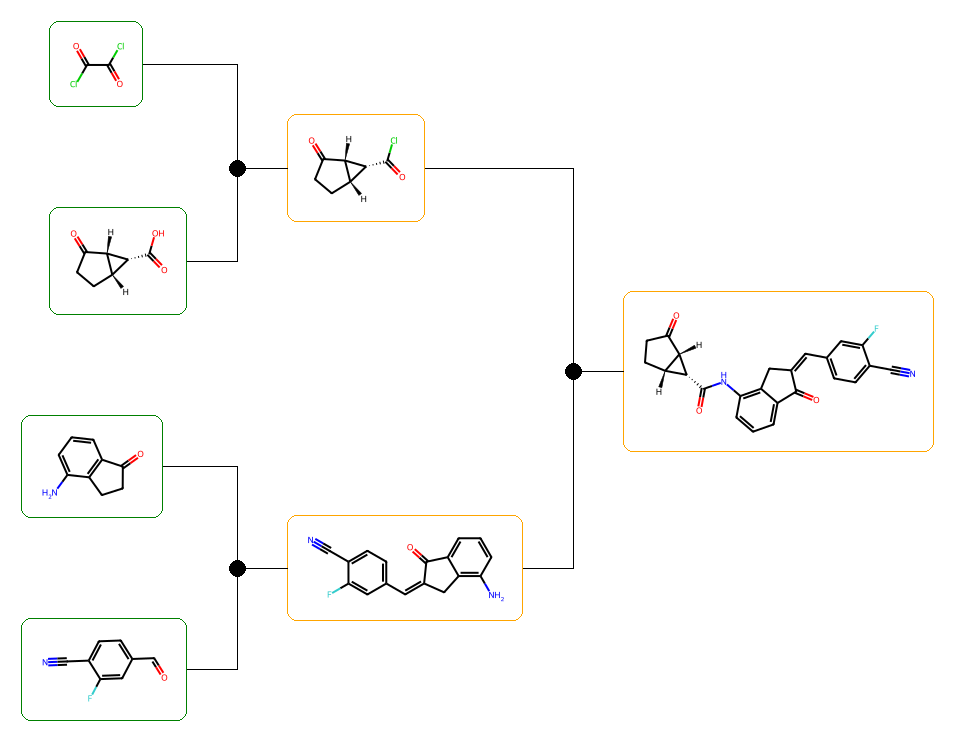

In [10]:
# pick the most likely (highest state score) route
best_route = max(trees, key=lambda route: route["scores"]["state score"])
print(best_route["scores"])

image = ReactionTree.from_dict(best_route).to_image()
image


In [11]:
import time
import requests


def get_pubchem_name(smiles: str) -> str | None:
    """Look up a compound's IUPAC name on PubChem by SMILES. Returns None if not found."""
    encoded = requests.utils.quote(smiles, safe="")
    url = (
        f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/smiles/"
        f"{encoded}/property/IUPACName/JSON"
    )
    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        return response.json()["PropertyTable"]["Properties"][0]["IUPACName"]
    except Exception:
        return None


def collect_mol_nodes(node, nodes=None):
    if nodes is None:
        nodes = []
    if node["type"] == "mol":
        nodes.append(node)
    for child in node.get("children", []):
        collect_mol_nodes(child, nodes)
    return nodes


for node in collect_mol_nodes(best_route):
    name = get_pubchem_name(node["smiles"])
    stock_tag = "in stock" if node.get("in_stock") else "intermediate"
    print(f"[{stock_tag}] {node['smiles']} -> {name or '(no name found)'}")
    time.sleep(0.2)


[intermediate] N#Cc1ccc(C=C2Cc3c(NC(=O)[C@@H]4[C@@H]5CCC(=O)[C@@H]54)cccc3C2=O)cc1F -> (no name found)
[intermediate] O=C(Cl)[C@@H]1[C@@H]2CCC(=O)[C@@H]21 -> (no name found)
[in stock] O=C(Cl)C(=O)Cl -> oxalyl dichloride
[in stock] O=C(O)[C@@H]1[C@@H]2CCC(=O)[C@@H]21 -> (1S,5R,6R)-2-oxobicyclo[3.1.0]hexane-6-carboxylic acid
[intermediate] N#Cc1ccc(C=C2Cc3c(N)cccc3C2=O)cc1F -> (no name found)
[in stock] Nc1cccc2c1CCC2=O -> 4-amino-2,3-dihydroinden-1-one
[in stock] N#Cc1ccc(C=O)cc1F -> 2-fluoro-4-formylbenzonitrile
